In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from collections import defaultdict
import pprint

import hydra
from omegaconf import OmegaConf
import torch
import pandas as pd
import seaborn as sns
sns.set_theme(style='whitegrid', font_scale=1.3, palette=sns.color_palette('Set2'),)
import sqlalchemy as sa

from conf import conf
from rna_vel_pred import datasets, utils

/home/reepoi/GitHub/velocityPrediction-new/.venv/lib/python3.10/site-packages/torch_geometric/typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: /home/reepoi/GitHub/velocityPrediction-new/.venv/lib/python3.10/site-packages/libpyg.so: undefined symbol: _ZN5torch8autograd12VariableInfoC1ERKN2at6TensorE
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/home/reepoi/GitHub/velocityPrediction-new/.venv/lib/python3.10/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /home/reepoi/GitHub/velocityPrediction-new/.venv/lib/python3.10/site-packages/torch_scatter/_scatter_cuda.so: undefined symbol: _ZN2at4_ops16div__Tensor_mode4callERNS_6TensorERKS2_St8optionalIN3c1017basic_string_viewIcEEE
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/home/reepoi/GitHub/velocityPrediction-new/.venv/lib/python3.10/site-packages/tor

In [3]:
# os.environ['CUDA_VISIBLE_DEVICES'] = '0'

In [4]:
with hydra.initialize(version_base=utils.HYDRA_INIT['version_base'], config_path='../conf'):
    cfg = hydra.compose(utils.HYDRA_INIT['config_name'], overrides=[
        'datasets=[{_target_:conf.datasets.H5adUMap,dataset:PANCREAS,umap_dimension:2}]',
        # 'datasets=[{_target_:conf.datasets.SimpleMotif}]',
        'model=First',
    ])
    engine = conf.get_engine()
    conf.orm.create_all(engine)
    with conf.sa.orm.Session(engine) as db:
        cfg = conf.orm.instantiate_and_insert_config(db, OmegaConf.to_container(cfg, resolve=True))
        pprint.pp(cfg)

Conf(root_dir='/home/reepoi/GitHub/velocityPrediction-new',
     out_dir='/home/reepoi/out/rna_vel_pred-new',
     data_subdir='/home/reepoi/out/rna_vel_pred-new/data_redesign',
     run_subdir='runs',
     prediction_filename='prediction.parquet',
     device='cuda',
     alt_id='zscqax1l',
     rng_seed=2376999025,
     fit=True,
     predict=False,
     is_optuna_sweep=False,
     id=6,
     datasets=[H5adUMap(time_step_count_sparsify=10,
                        neighbor_count=10,
                        frac_train=0.7,
                        frac_val=0.2,
                        frac_test=0.1,
                        batch_size=10,
                        limit_batch_count_train=0,
                        batch_count_train=10,
                        reverse_velocities=False,
                        id=1,
                        dataset=<UMapDataset.PANCREAS: 'PANCREAS'>,
                        processed_filename='y4490rcr',
                        umap_dimension=2)],
     model=

In [5]:
splits = datasets.get_merged_dataset(cfg, cfg.data_dir, rng_seed=cfg.rng_seed)

Seed set to 2376999025
Seed set to 2376999025


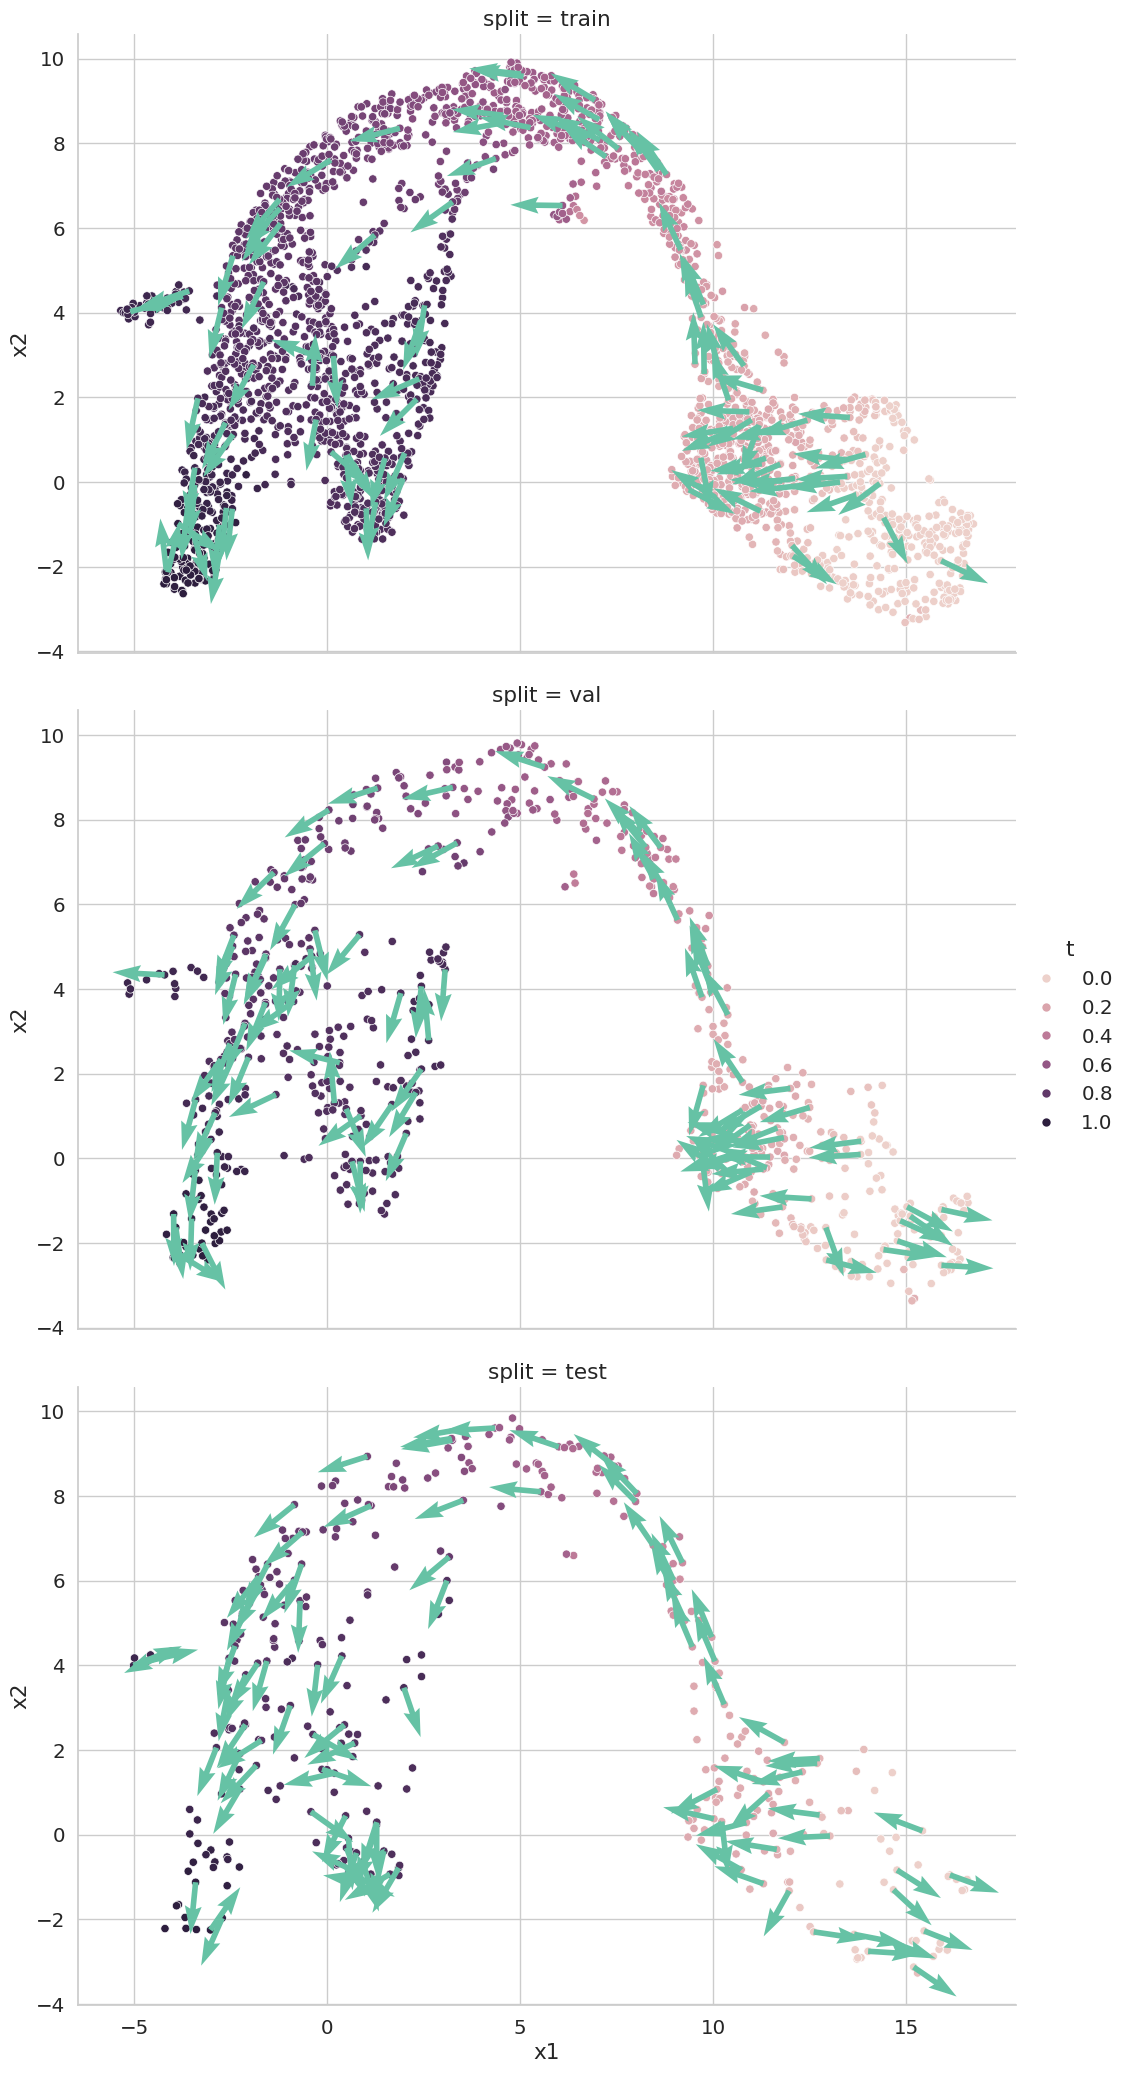

In [6]:
dfs = []
for split, dataset in splits.items():
    data = dataset.data
    df = pd.DataFrame(dict(
        measurement_id=data.poi_measurement_id,
        split=split,
        t=data.poi_t,
        **{f'x{i+1}': poi_pos_dim for i, poi_pos_dim in enumerate(data.poi_pos.T)},
        **{f'v{i+1}': poi_vel_dim for i, poi_vel_dim in enumerate(data.poi_vel.T)},
    ))
    dfs.append(df)
df = pd.concat(dfs, ignore_index=True)
plot = (
    sns.relplot(
        kind='scatter',
        data=df,
        row='split',
        hue='t',
        x='x1', y='x2',
        height=7,
        aspect=1.5,
    )
)
for (row, col, hue), data in plot.facet_data():
    ax = plot.axes[row][col]
    data = data.sample(100)
    ax.quiver(
        data['x1'], data['x2'], data['v1'], data['v2'],
        # headwidth=1, headlength=15, headaxislength=2,
        color=None,
    )

In [7]:
df.sort_values('t')

,measurement_id,split,t,x1,x2,v1,v2
2301,2325,train,0.000000,14.576943,1.794712,-0.898865,0.438226
180,2403,train,0.000322,14.265138,0.112997,-0.999996,0.002881
2274,2904,train,0.000631,14.370734,0.211936,-0.993979,-0.109567
2254,372,train,0.000661,14.658670,1.503516,-0.918387,0.395683
1716,631,train,0.000676,14.732340,1.629638,-0.891472,0.453075
...,...,...,...,...,...,...,...
941,2073,train,0.999796,-3.958919,-1.821507,0.483757,-0.875202
805,2874,train,0.999841,-3.651835,-1.927328,0.819403,0.573218
2672,1120,val,0.999848,-2.897514,-2.012691,-0.180847,-0.983511
13,3071,train,0.999861,-3.404196,-1.925715,0.380145,0.924927


tensor([3286])
Data(pos=[10, 2], poi_pos=[1, 2], poi_vel=[1, 2], poi_t=[1], poi_measurement_id=[1], vel=[10, 2], t=[10])
tensor([[-0.9970, -0.9859, -0.9999, -0.9455, -0.8418,  0.5027,  0.2236, -0.9820,
         -0.9318, -0.9904],
        [ 0.0774,  0.1674, -0.0168,  0.3258, -0.5397, -0.8644, -0.9747, -0.1886,
          0.3629, -0.1383]])
    split         t      $x_1$     $x_2$     $v_1$     $v_2$  is_poi
0   train  0.036615  14.596540  1.698403 -0.931823  0.362914   False
1   train  0.041518  12.251427 -1.723917  0.223629 -0.974674   False
2   train  0.047486  13.017751 -0.892782 -0.841825 -0.539750   False
3   train  0.055235  13.388683  0.491642 -0.999859 -0.016766   False
4   train  0.062143  13.265765  0.428517 -0.997000  0.077401   False
5   train  0.067517  13.958679  1.762837 -0.978402  0.206712    True
6   train  0.072719  14.234847  1.717025 -0.985894  0.167373   False
7   train  0.078512  15.380555 -3.027251 -0.945455  0.325753   False
8   train  0.083945  12.181940 -1.39633

KeyError: 'x1'

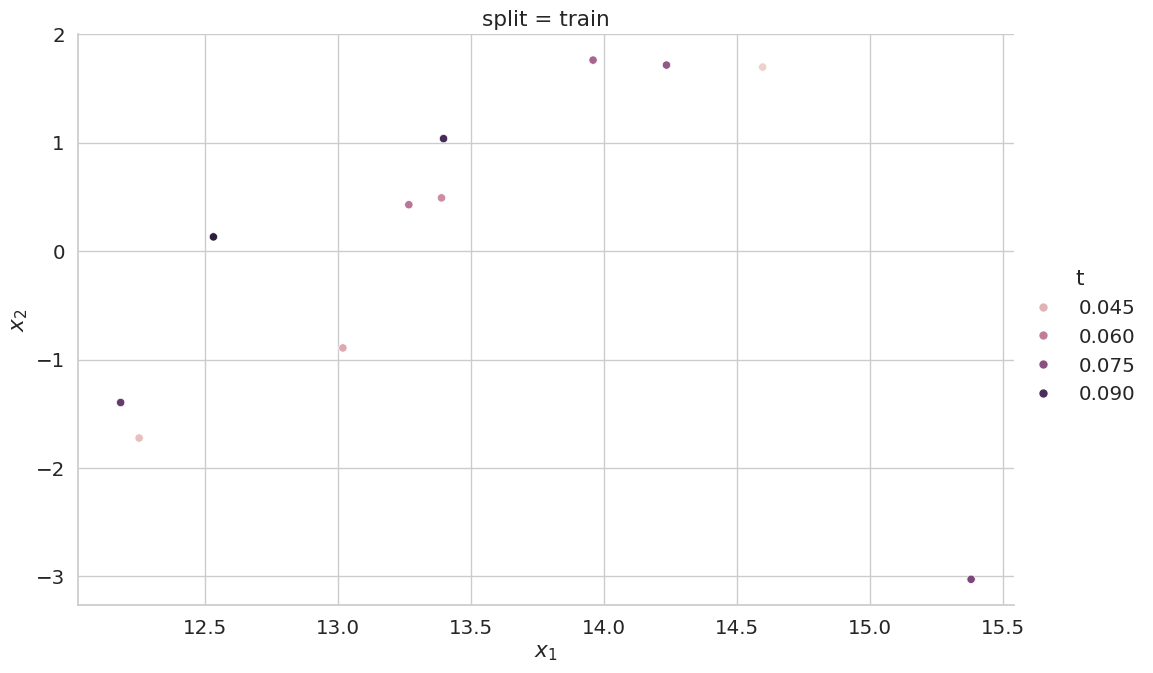

In [12]:
split = 'train'
data_idx = 11
dataset = splits[split]
data = dataset[data_idx]
print(data.poi_measurement_id)
print(data)
print(data.vel.T)
df = pd.DataFrame(dict(
    split=split,
    t=torch.cat([data.t, data.poi_t]),
    **{f'$x_{i+1}$': x for i, x in enumerate(torch.cat([data.pos, data.poi_pos]).T)},
    **{f'$v_{i+1}$': v for i, v in enumerate(torch.cat([data.vel, data.poi_vel]).T)},
    is_poi=False,
))
df.loc[df.index[-1], 'is_poi'] = True
df = df.sort_values('t', ignore_index=True)
print(df)
plot = (
    sns.relplot(
        kind='scatter',
        data=df,
        row='split',
        hue='t',
        x='$x_1$', y='$x_2$',
        height=7,
        aspect=1.5,
    )
)
for (row, col, hue), data in plot.facet_data():
    ax = plot.axes[row][col]
    ax.quiver(
        data['x1'], data['x2'], data['v1'], data['v2'],
        # headwidth=1, headlength=15, headaxislength=2,
        color=None,
        zorder=0,
    )
    data_poi = data.query('is_poi')
    ax.plot(data_poi['x1'], data_poi['x2'], 'kx', markersize=10, zorder=0)